### Plot Gen information for boosted tau massregression sample 

In [5]:
import awkward as ak
from coffea import processor
from coffea.nanoevents.methods import candidate
import uproot
from coffea.nanoevents import NanoEventsFactory, BaseSchema
import json
import hist
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
import pickle, glob
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)



In [16]:
class MyProcessor(processor.ProcessorABC):
    def __init__(self):
        pass

    def process(self, events):
        # print(events.jetadR)
        # dataset_axis = hist.axis.StrCategory([], growth=True, name="dataset", label="Primary dataset")
        # dR_axis = hist.axis.Regular(10, 0, 0.5, name="dR", label="Jet A dR")
        dataset = events.metadata['dataset']
        # print("jetE--------------------",events.jetE)
        jet = ak.zip(
            {
                "GenA1_inv":ak.flatten(events.a_m),
                "A1_pt": ak.flatten(events.a_pt),
                
                
               
            },
            with_name="PtEtaPhiMCandidate",
            behavior=candidate.behavior,
         
        )
        
        
        amass = jet.GenA1_inv[jet.GenA1_inv > -22.22]
        
        apt = jet.A1_pt[jet.A1_pt>-22.22]
        
        
        
        # A mass  -----------------------------------------------------------
        
        A_mass = (
            hist.Hist.new
            .StrCat(["A mass"], name="hmassa")
            .Reg(37, 3.6, 18, name="massa", label="Mass [GeV]")
             # .Reg(7, 1.2, 3.6, name="massa", label="Mass [GeV]")
            .Int64()
        )
        A_mass.fill(hmassa="A mass", massa=amass)


        # A pt  -----------------------------------------------------------
        
        A_pt = (
            hist.Hist.new
            .StrCat([ "A_pt"], name="hapt")
            .Reg(55, 30, 300, name="pt_a", label="pT [GeV]")
            .Int64()
        )
        
        A_pt.fill(hapt="A_pt", pt_a=apt)
       
        
        A_mass_pt = (
            hist.Hist.new
            
            .Reg(37, 3.6, 18, name="massa", label="Mass [GeV]")
            # .Reg(7, 1.2, 3.6, name="massa", label="Mass [GeV]")
            .Reg(55, 30, 300, name="pt_a", label="pT [GeV]").Int64()
        )
        A_mass_pt.fill(massa=amass, pt_a=apt)

        
        #----------------------------------------------------------------------------------
        
       
        
        
        
        return {
            dataset: {
                "entries": len(events),

                "a_mass":A_mass,
                
                "a_pt":A_pt,

                "a_mass_pt":A_mass_pt,
                
               
                
              
               
            }
        }

    def postprocess(self, accumulator):
        pass

In [17]:
with open("ATo2Tau_m3p6To18_pt30To300_full.json", "r") as fin:
    file_list_train1 = json.load(fin) 
# with open("aToTauTau_massreg_dataset_2.json", "r") as fin:
#     file_list_train2 = json.load(fin) 

fileset = {
    'train_dataset_physical': file_list_train1 
    # ,'train_dataset_2': file_list_train2
                  
}


In [18]:
futures_run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=10),
    schema=BaseSchema,
    # maxchunks=1,
)

out = futures_run(
    fileset,
    treename='/fevt/RHTree',
    processor_instance=MyProcessor()
)
with open('ATo2Tau_m3p6To18_pt30To300_full.pkl', 'wb') as f:
    pickle.dump(out, f)

print("Output saved to ATo2Tau_m3p6To18_pt30To300_full.pkl")

Output()

Output()

Output saved to ATo2Tau_m3p6To18_pt30To300_full.pkl


Total events 517101


(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation'))

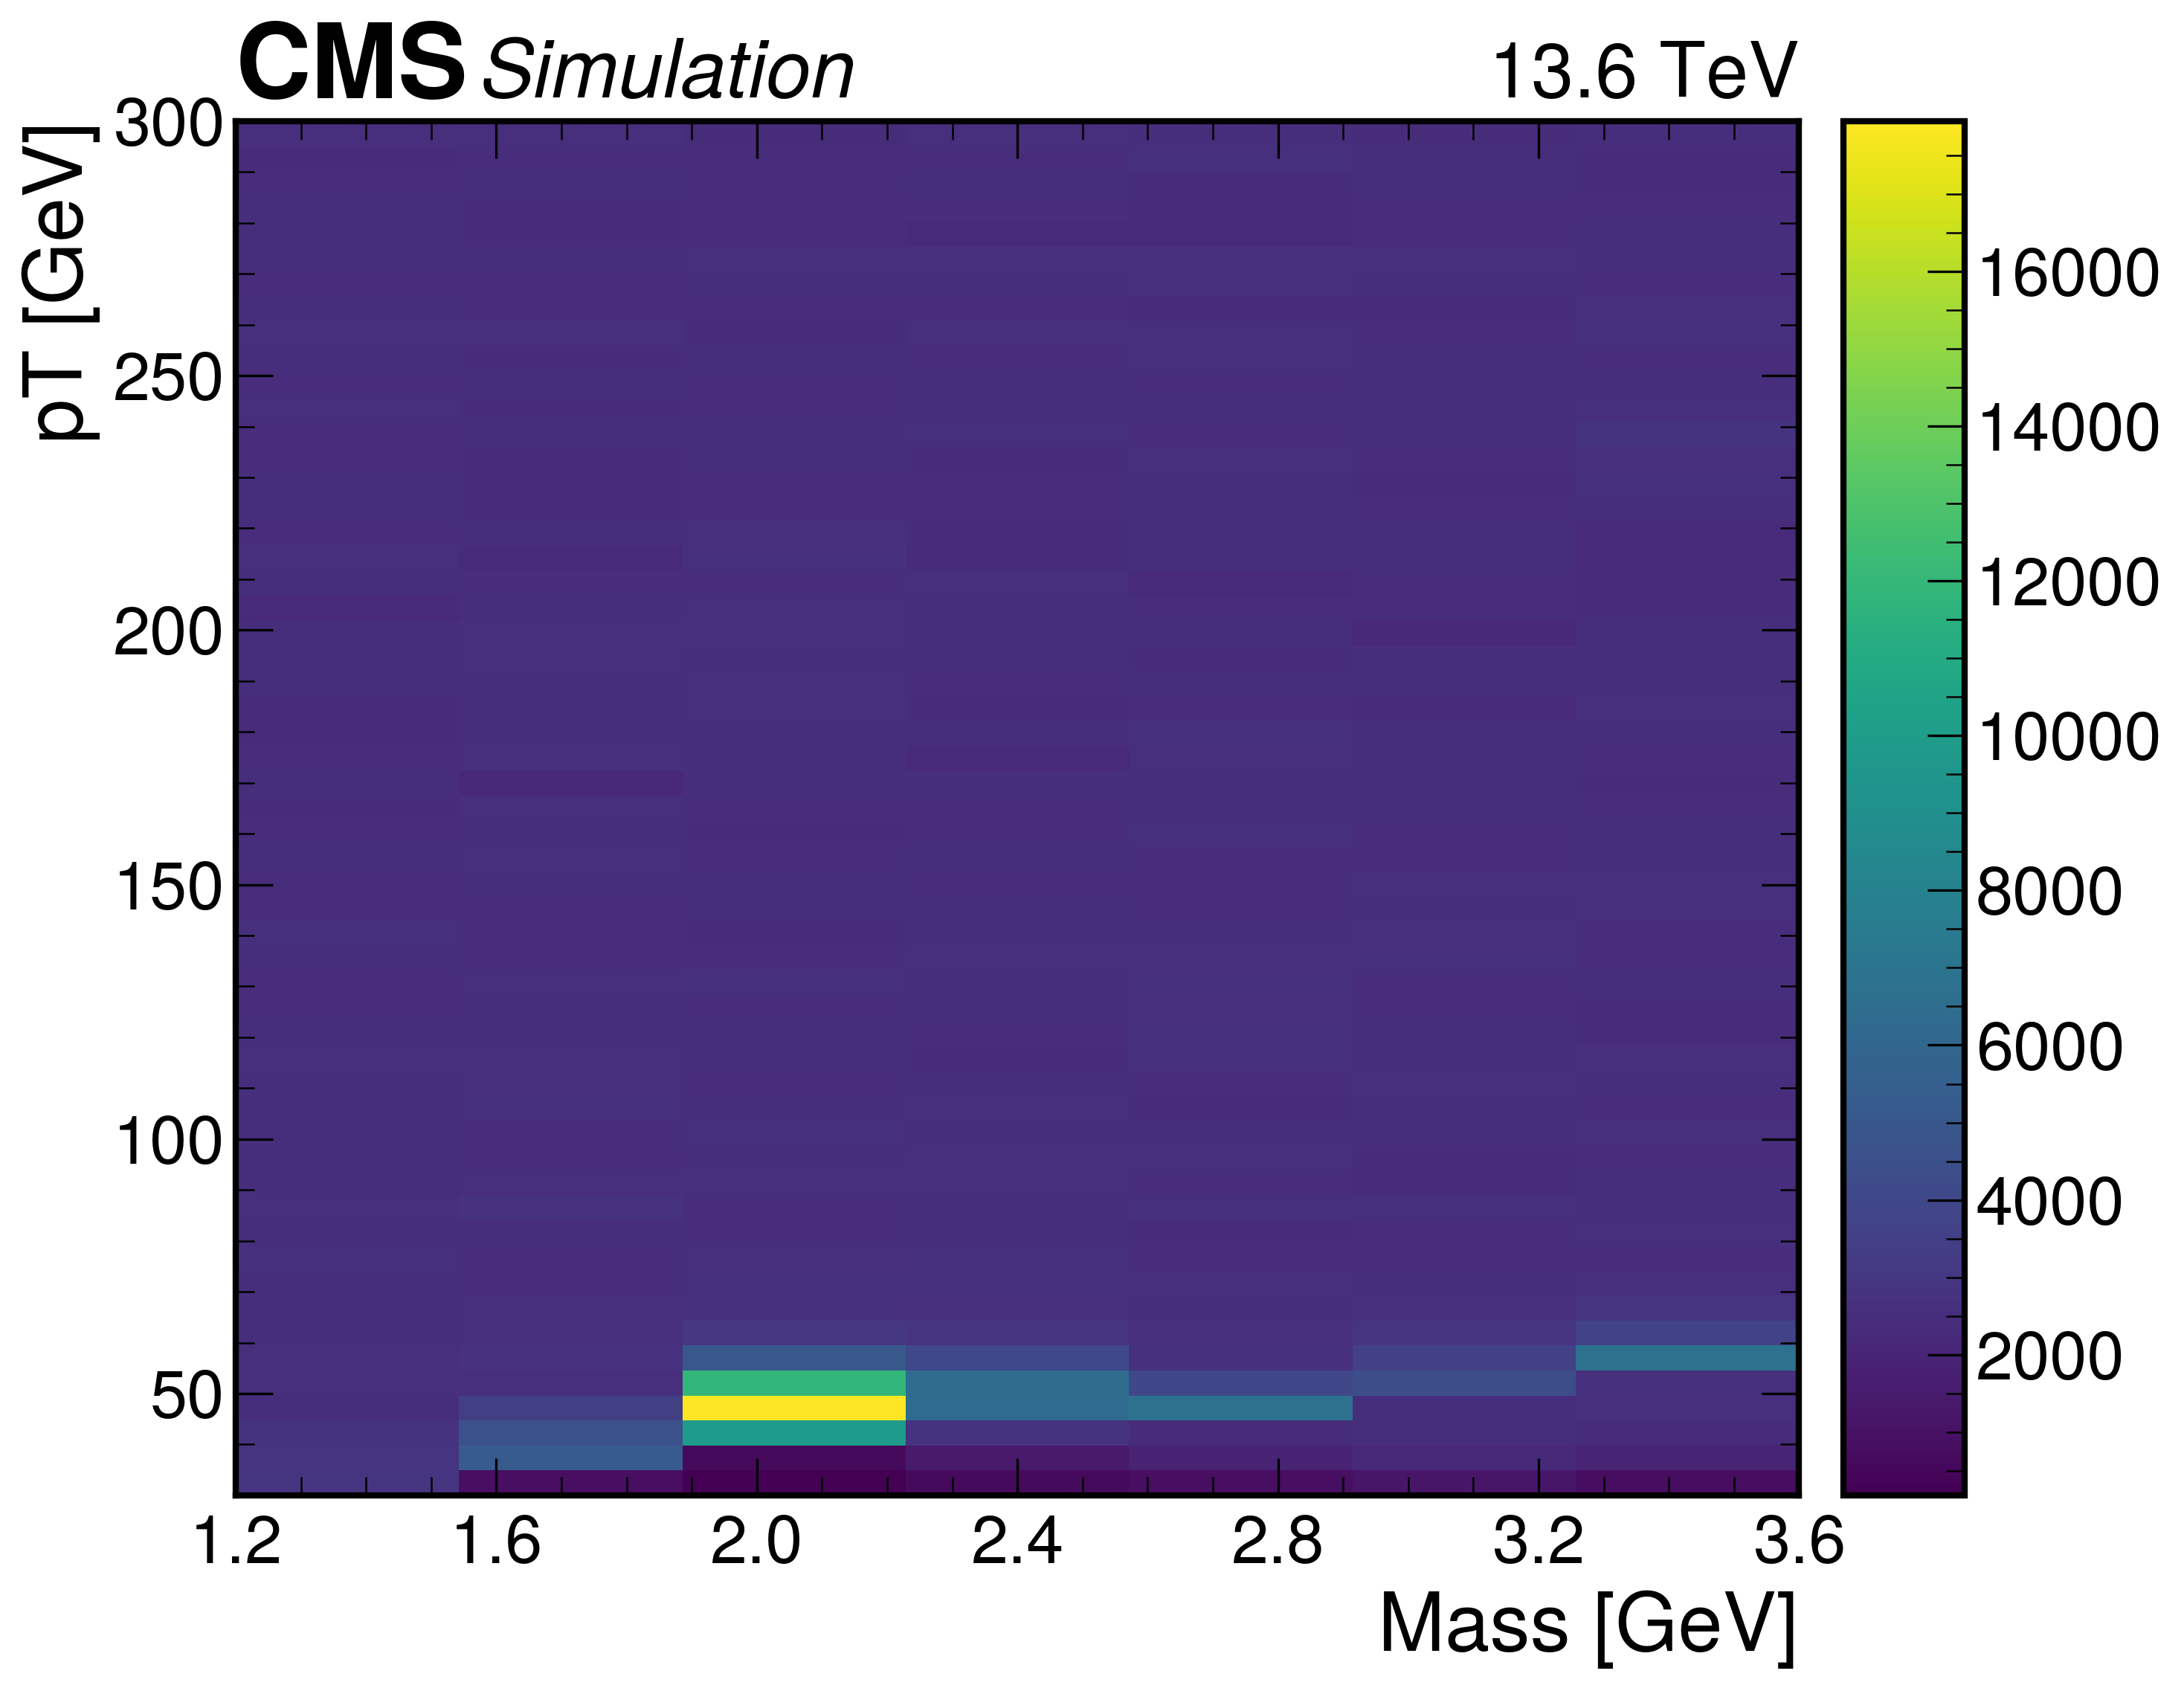

In [40]:
with open('ATo2Tau_m1p2To3p6_pt30To300_full.pkl', 'rb') as f:
    out = pickle.load(f)
print("Total events", out["train_dataset_unphysical"]["entries"])
fig, ax = plt.subplots(dpi=300,figsize=(10,8))
norm = mcolors.TwoSlopeNorm(vmin=0, vmax = 2000, vcenter=500)
out["train_dataset_unphysical"]["a_mass_pt"].plot2d()
ax.set_xticks(np.round(np.arange(1.2, 3.6, 0.4), 1))
# ax.set_yticks(np.arange(30, 300, 5), minor=True)
# plt.xticks(np.arange(3.2,17.2,1.2))
# plt.grid(which='both')
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'plots_massreg_dataset_1/a_mass_pt_2d_hist.png',facecolor='w',dpi=300)

### for dataset 1

Total events 2945089


(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation Preliminary'))

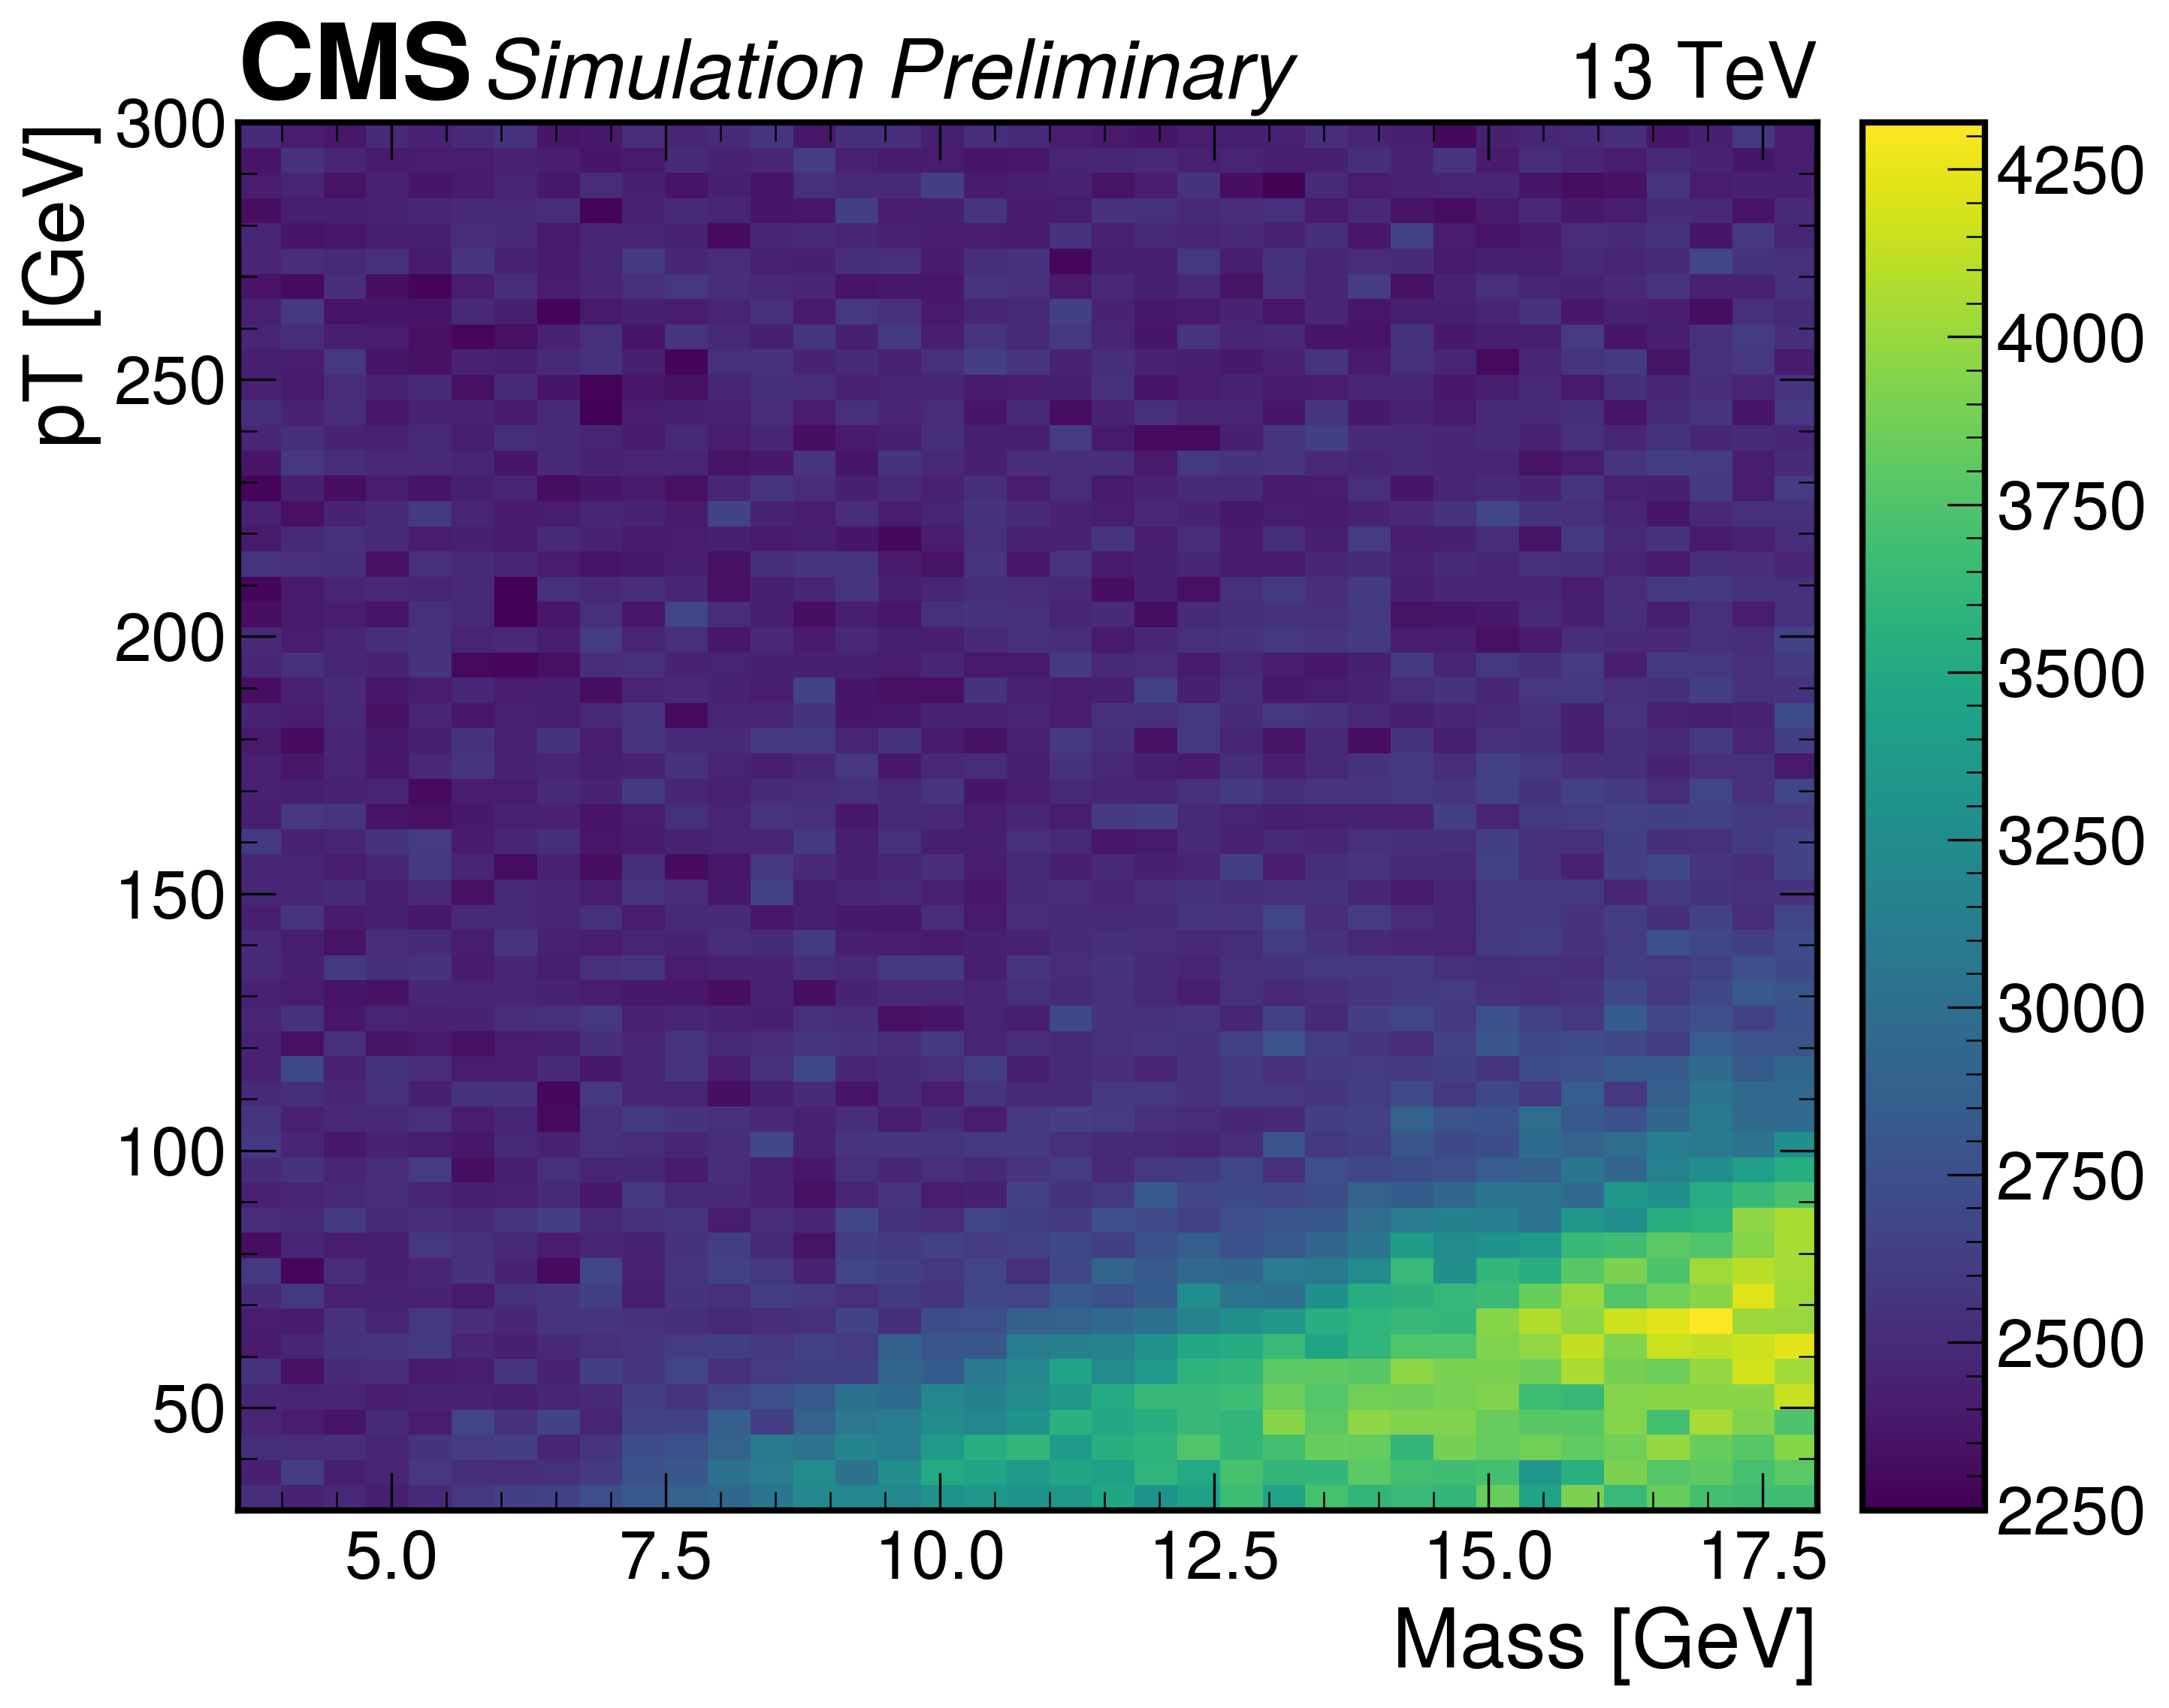

In [39]:
with open('ATo2Tau_m3p6To18_pt30To300_full.pkl', 'rb') as f:
    out = pickle.load(f)
print("Total events", out["train_dataset_physical"]["entries"])
fig, ax = plt.subplots(dpi=300,figsize=(10,8))
norm = mcolors.TwoSlopeNorm(vmin=0, vmax = 2000, vcenter=500)
out["train_dataset_physical"]["a_mass_pt"].plot2d()
# ax.set_xticks(np.arange(1.2, 3.7, 0.4), minor=True)
# ax.set_yticks(np.arange(30, 300, 5), minor=True)
# plt.xticks(np.arange(3.6,18.1,1.6))
# plt.grid(which='both')
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
# plt.savefig(f'plots_massreg_dataset_1/a_mass_pt_2d_hist.png',facecolor='w',dpi=300)

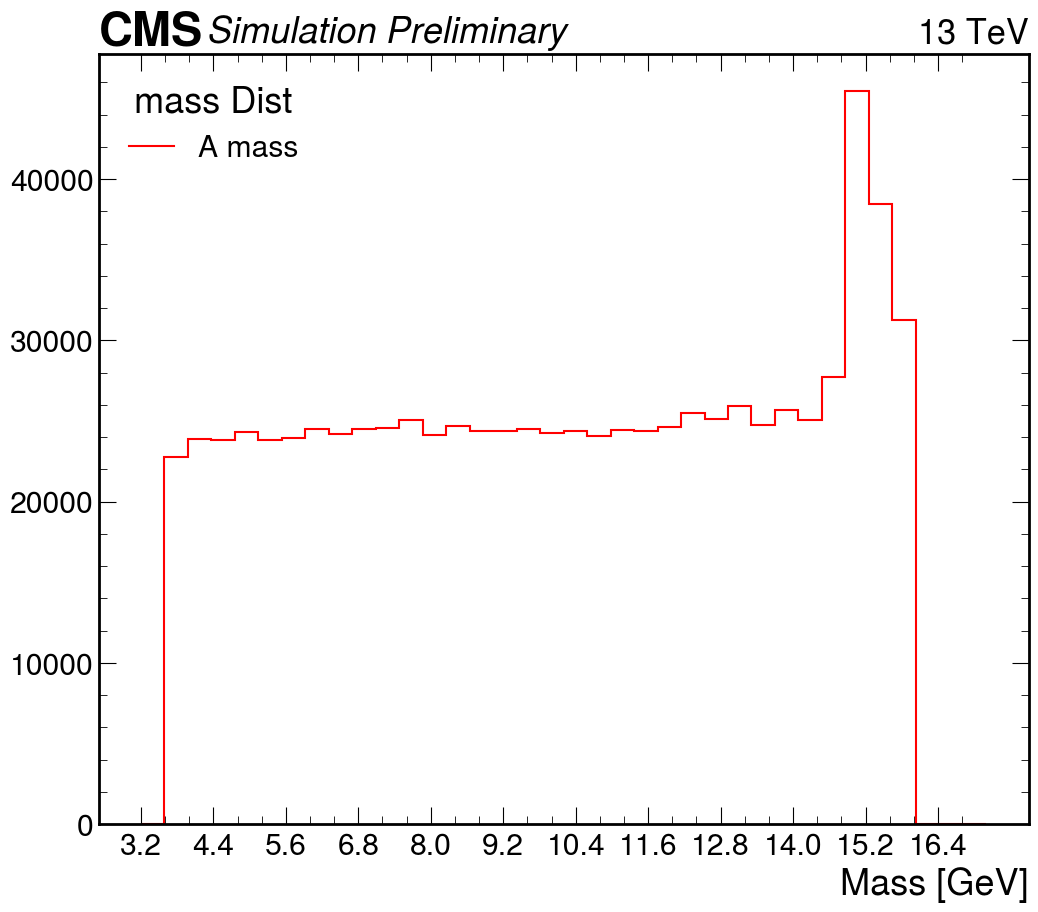

In [82]:
fig, ax = plt.subplots(figsize=(12,10))
out["train_dataset_1"]["a_mass"].plot1d(ax=ax,histtype='step',color="r")
ax.legend(title="mass Dist")
ax.set_xticks(np.arange(3.2, 17.2, 0.4), minor=True)
plt.xticks(np.arange(3.2,17.2,1.2))
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/a_mass_1d_hist.png',facecolor='w',dpi=300)

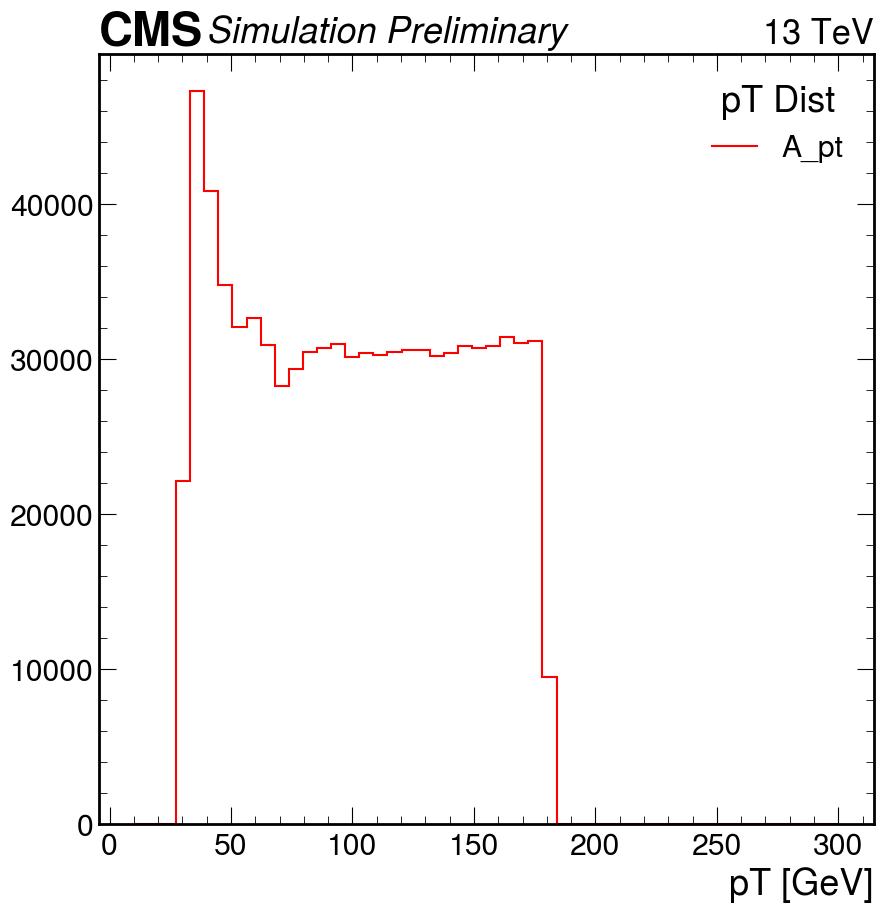

In [13]:
fig, ax = plt.subplots()
out["train_dataset_1"]["a_pt"].plot1d(ax=ax,histtype='step',color="r")
# out["train_mass"]["tau2_pt"].plot1d(ax=ax,histtype='step',color="b")
# ax.set_yscale("log")
ax.legend(title="pT Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/a_pt_1d_hist.png',facecolor='w',dpi=300)

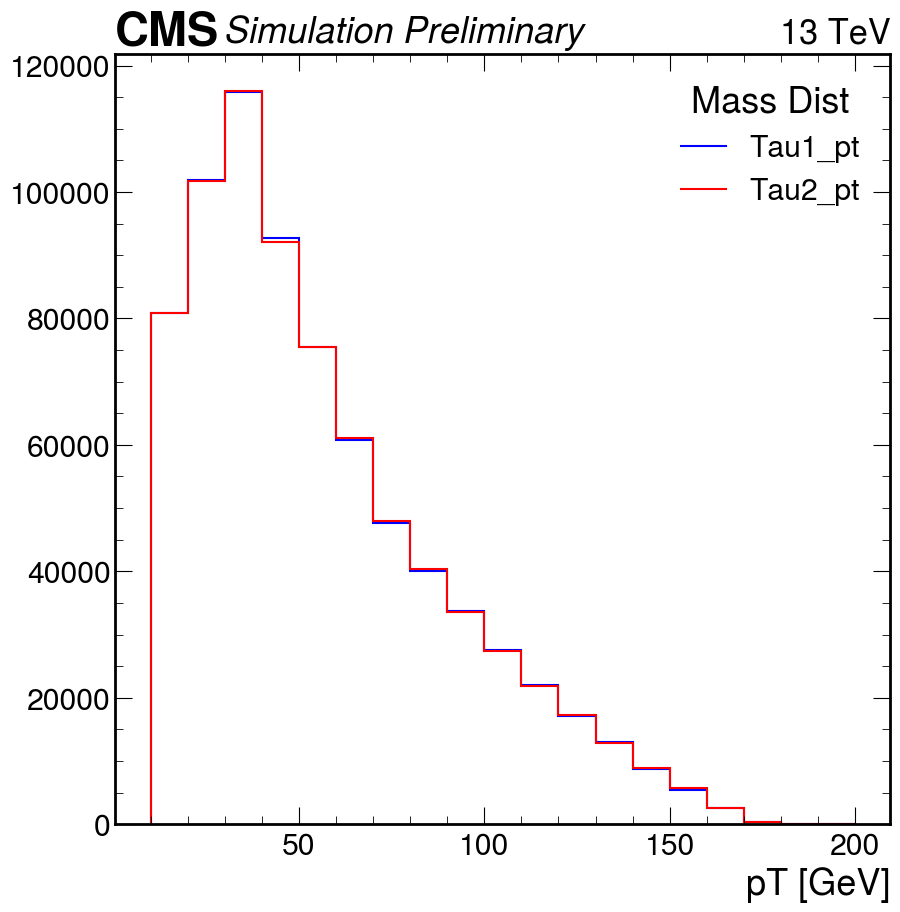

In [15]:
fig, ax = plt.subplots()
out["train_dataset_1"]["tau1_pt"].plot1d(ax=ax,histtype='step',color='b')
out["train_dataset_1"]["tau2_pt"].plot1d(ax=ax,histtype='step', color='r')

# ax.set_yscale("log")
ax.legend(title="Mass Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/tau1pttau2pt_hist.png',facecolor='w',dpi=300)

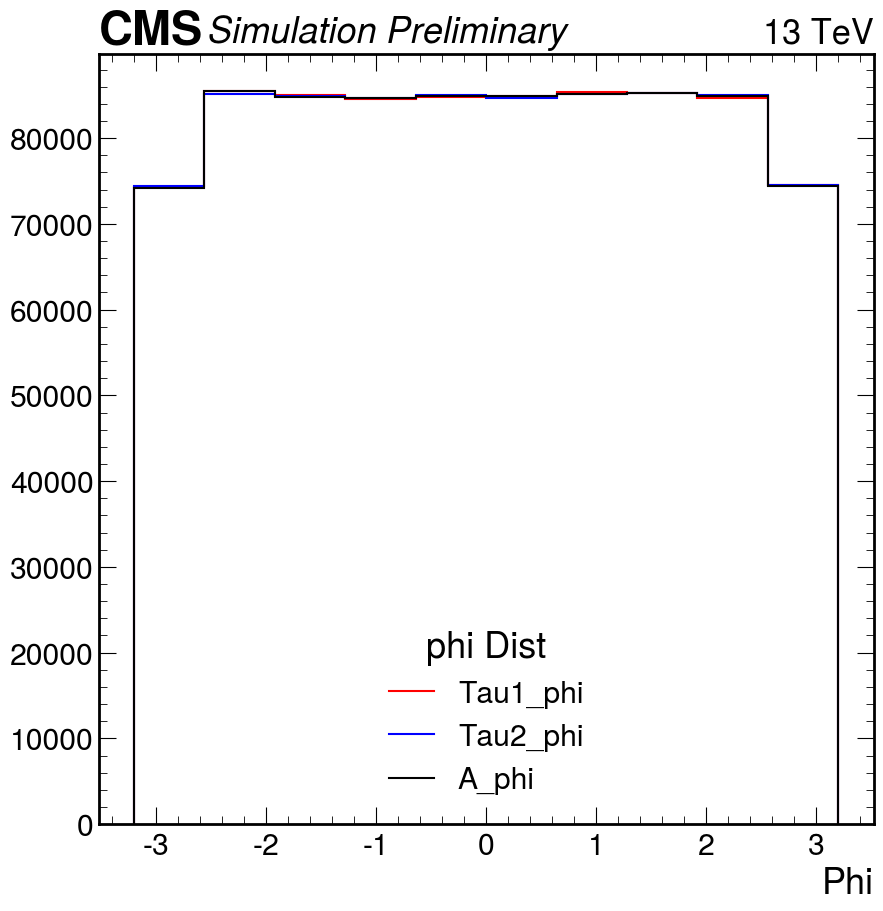

In [17]:
fig, ax = plt.subplots()
out["train_dataset_1"]["tau1_phi"].plot1d(ax=ax,histtype='step',color="r")
out["train_dataset_1"]["tau2_phi"].plot1d(ax=ax,histtype='step',color="b")
out["train_dataset_1"]["a_phi"].plot1d(ax=ax,histtype='step',color="black")
# ax.set_yscale("log")
ax.legend(title="phi Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/phi_dist_hist.png',facecolor='w',dpi=300)

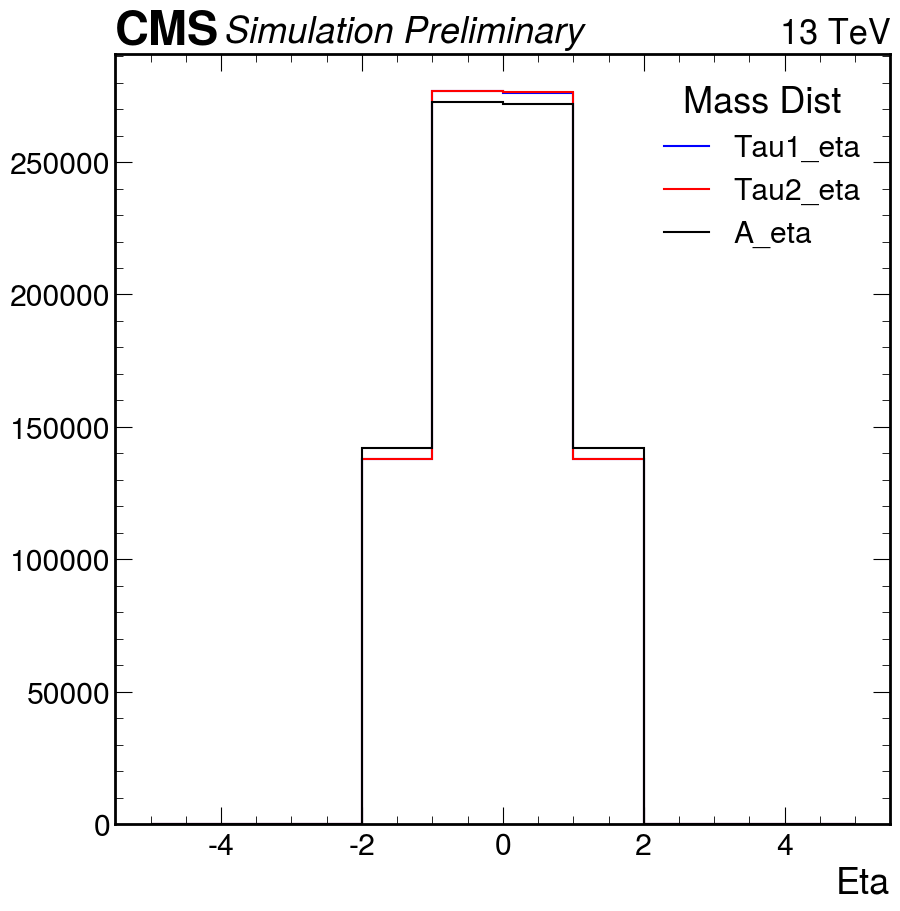

In [19]:
fig, ax = plt.subplots()
out["train_dataset_1"]["tau1_eta"].plot1d(ax=ax,histtype='step',color='b')
out["train_dataset_1"]["tau2_eta"].plot1d(ax=ax,histtype='step', color='r')
out["train_dataset_1"]["a_eta"].plot1d(ax=ax,histtype='step',color="black")
# ax.set_yscale("log")
ax.legend(title="Mass Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/eta_dist_hist.png',facecolor='w',dpi=300)

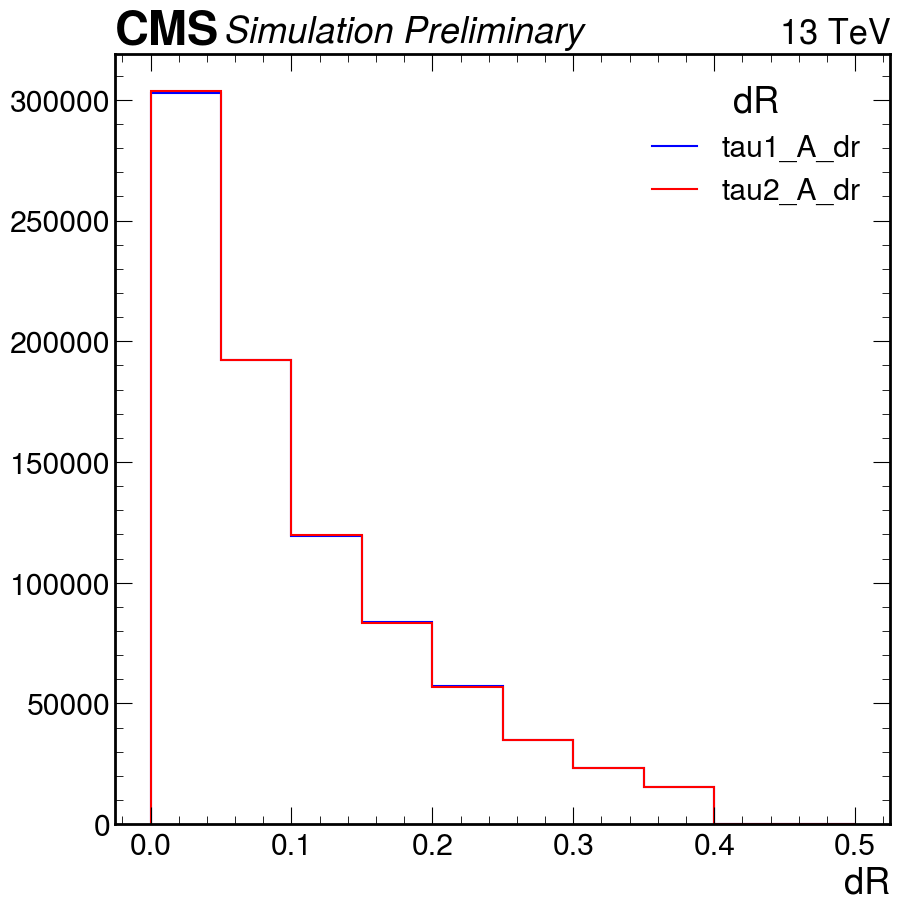

In [21]:
fig, ax = plt.subplots()
out["train_dataset_1"]["tau1_A_dr"].plot1d(ax=ax,histtype='step',color='b')
out["train_dataset_1"]["tau2_A_dr"].plot1d(ax=ax,histtype='step', color='r')

# ax.set_yscale("log")
ax.legend(title="dR")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/A_tau_dR_hist.png',facecolor='w',dpi=300)

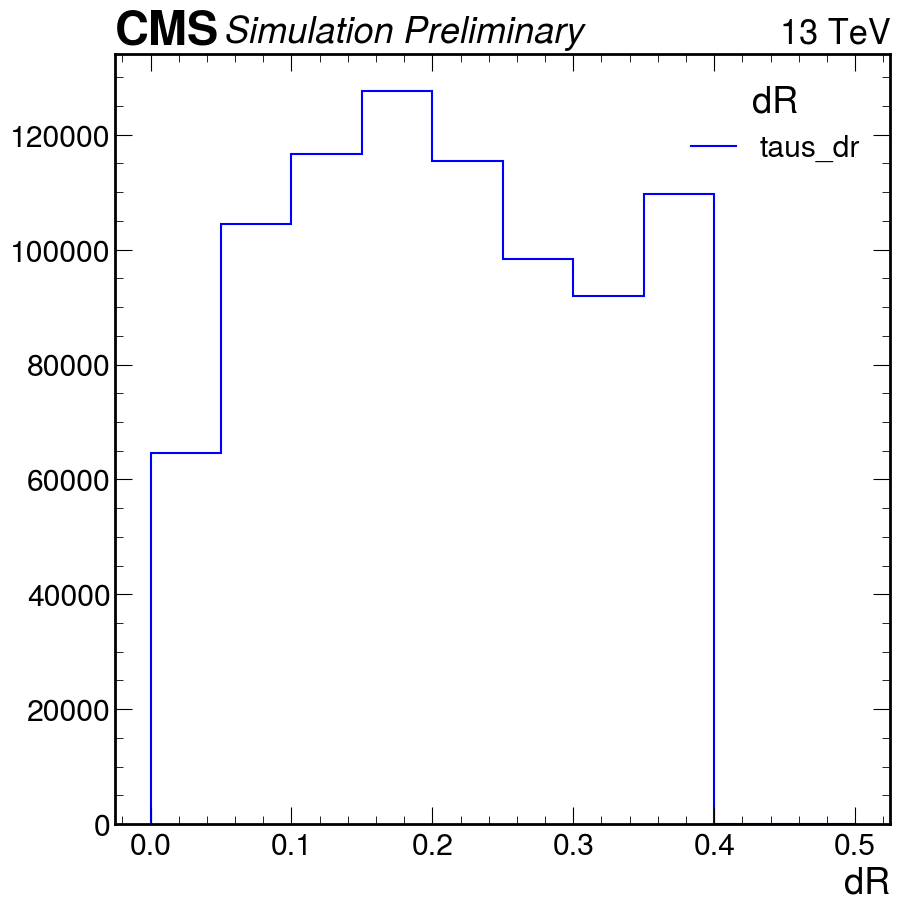

In [24]:
fig, ax = plt.subplots()
out["train_dataset_1"]["taus_dr"].plot1d(ax=ax,histtype='step',color='b')

# ax.set_yscale("log")
ax.legend(title="dR")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_1/tau_tau_dR_hist.png',facecolor='w',dpi=300)

### for dataset 2

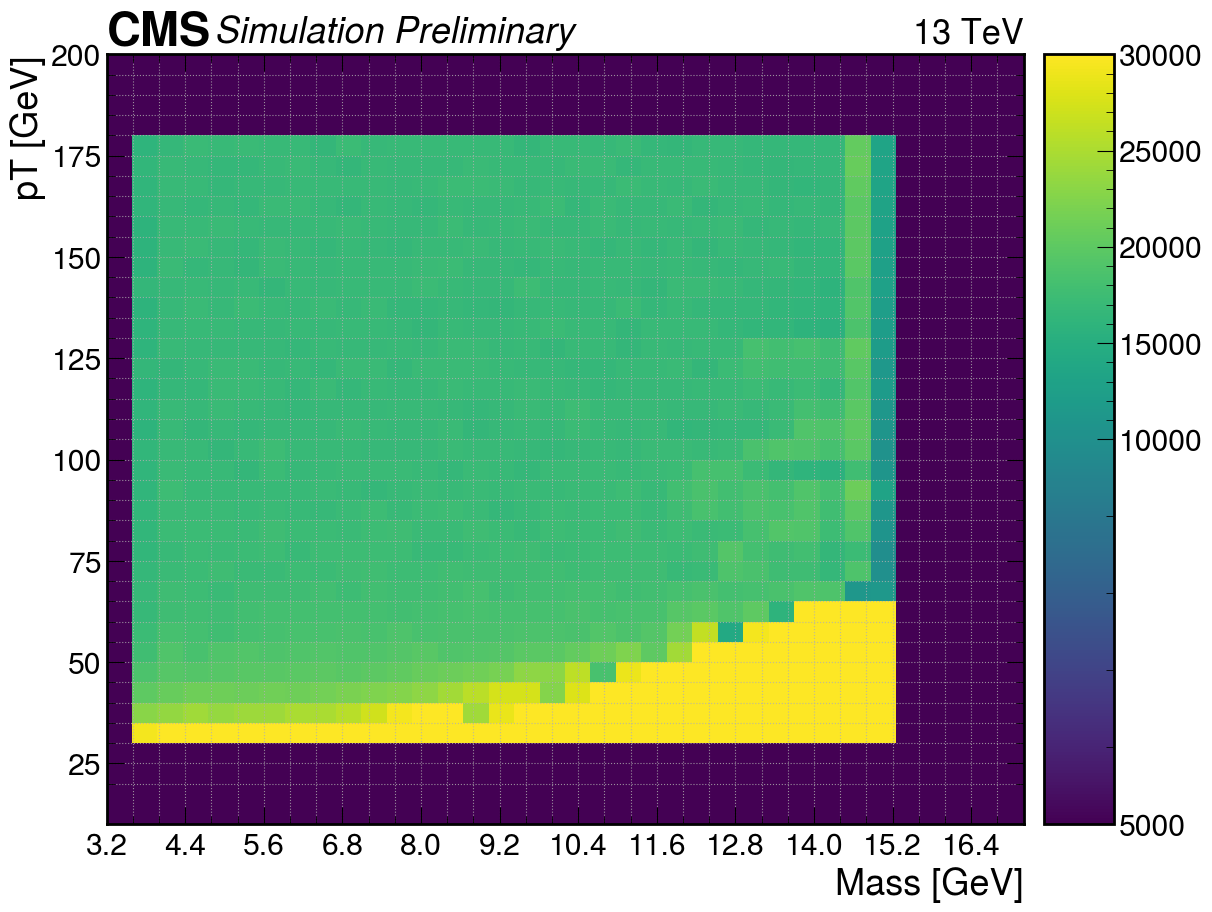

In [65]:
fig, ax = plt.subplots(figsize=(13,10))
norm = mcolors.TwoSlopeNorm(vmin=5000, vmax = 30000, vcenter=10000)
out["train_dataset_2"]["a_mass_pt"].plot2d(norm=norm)
ax.set_xticks(np.arange(3.2, 17.2, 0.4), minor=True)
ax.set_yticks(np.arange(20, 200, 5), minor=True)
plt.xticks(np.arange(3.2,17.2,1.2))
plt.grid(which='both')
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/a_mass_pt_2d_hist.png',facecolor='w',dpi=300)

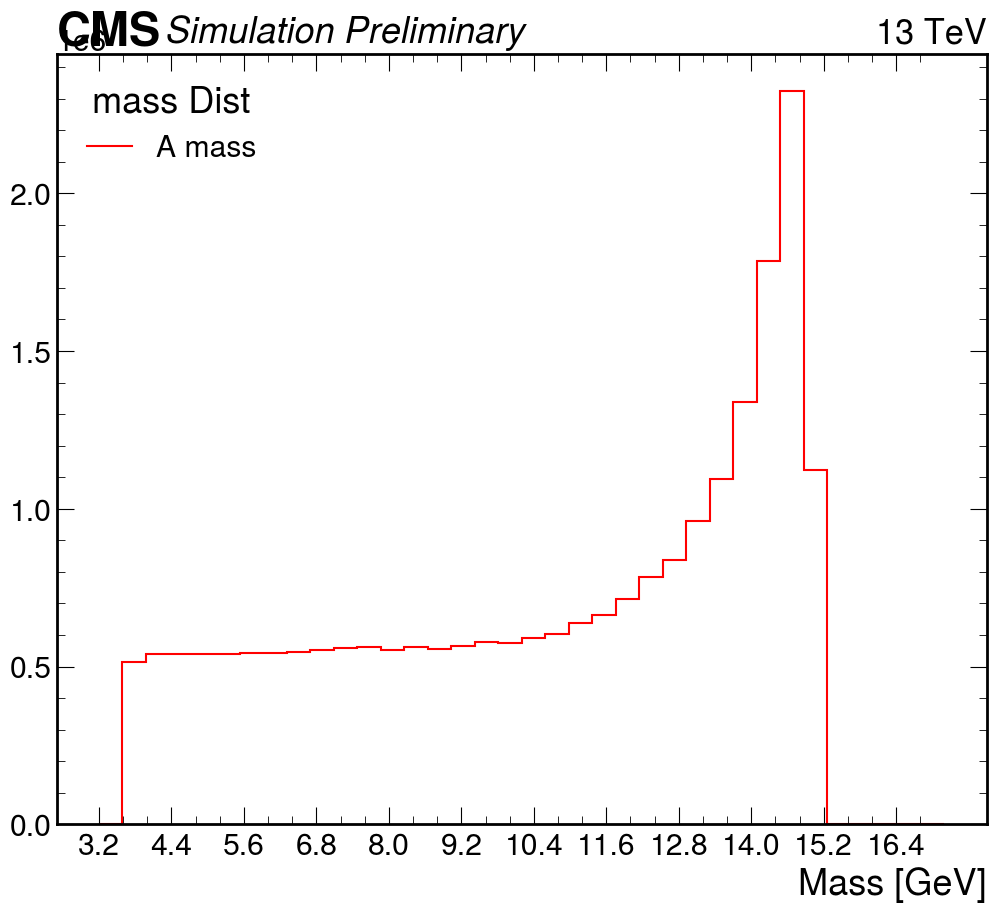

In [80]:
fig, ax = plt.subplots(figsize=(12,10))
out["train_dataset_2"]["a_mass"].plot1d(ax=ax,histtype='step',color="r")
ax.legend(title="mass Dist")
ax.set_xticks(np.arange(3.2, 17.2, 0.4), minor=True)
plt.xticks(np.arange(3.2,17.2,1.2))
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/a_mass_1d_hist.png',facecolor='w',dpi=300)

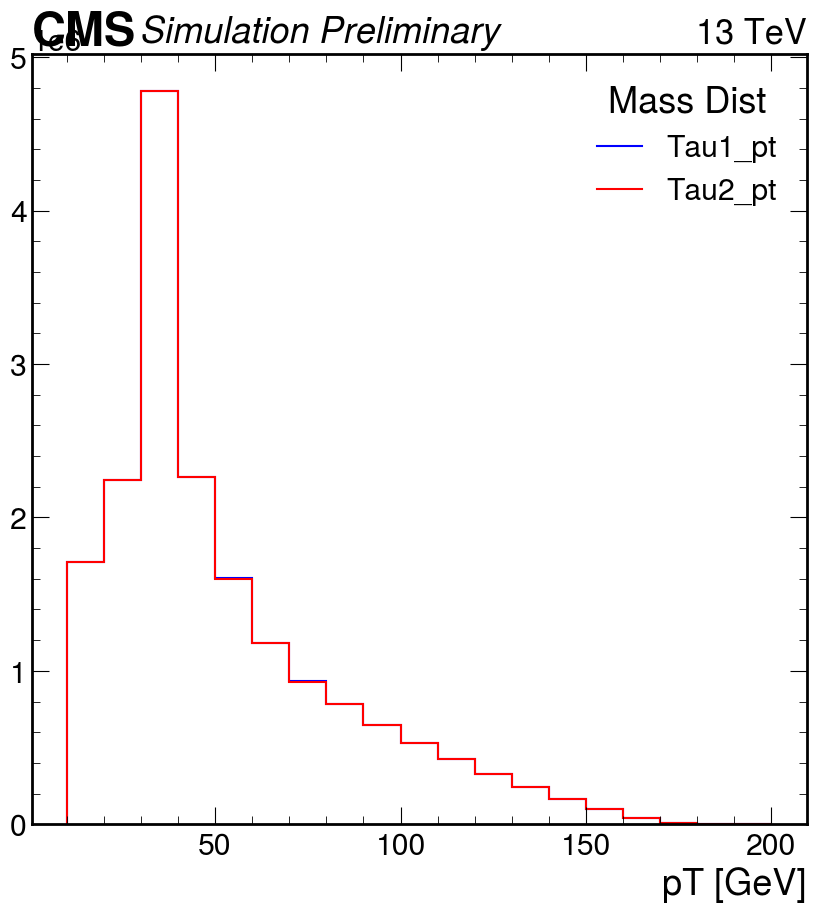

In [72]:
fig, ax = plt.subplots()
out["train_dataset_2"]["tau1_pt"].plot1d(ax=ax,histtype='step',color='b')
out["train_dataset_2"]["tau2_pt"].plot1d(ax=ax,histtype='step', color='r')
# ax.set_yscale("log")
ax.legend(title="Mass Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/tau1pttau2pt_hist.png',facecolor='w',dpi=300)

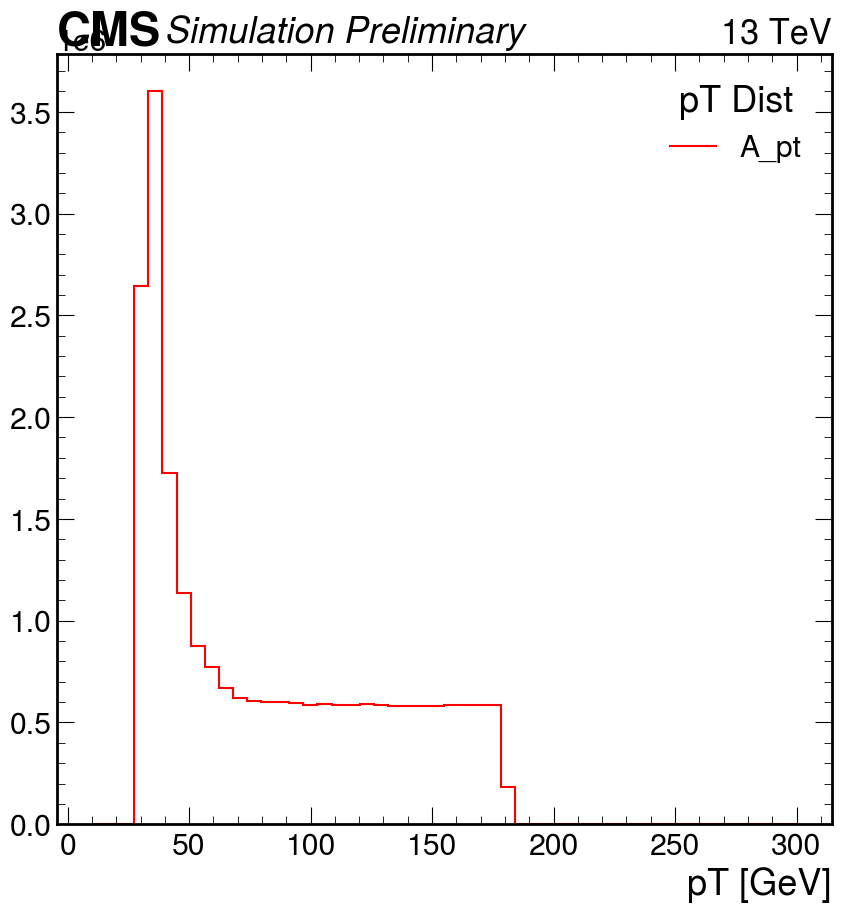

In [14]:
fig, ax = plt.subplots()
out["train_dataset_2"]["a_pt"].plot1d(ax=ax,histtype='step',color="r")
# out["train_mass"]["tau2_pt"].plot1d(ax=ax,histtype='step',color="b")
# ax.set_yscale("log")
ax.legend(title="pT Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/a_pt_1d_hist.png',facecolor='w',dpi=300)

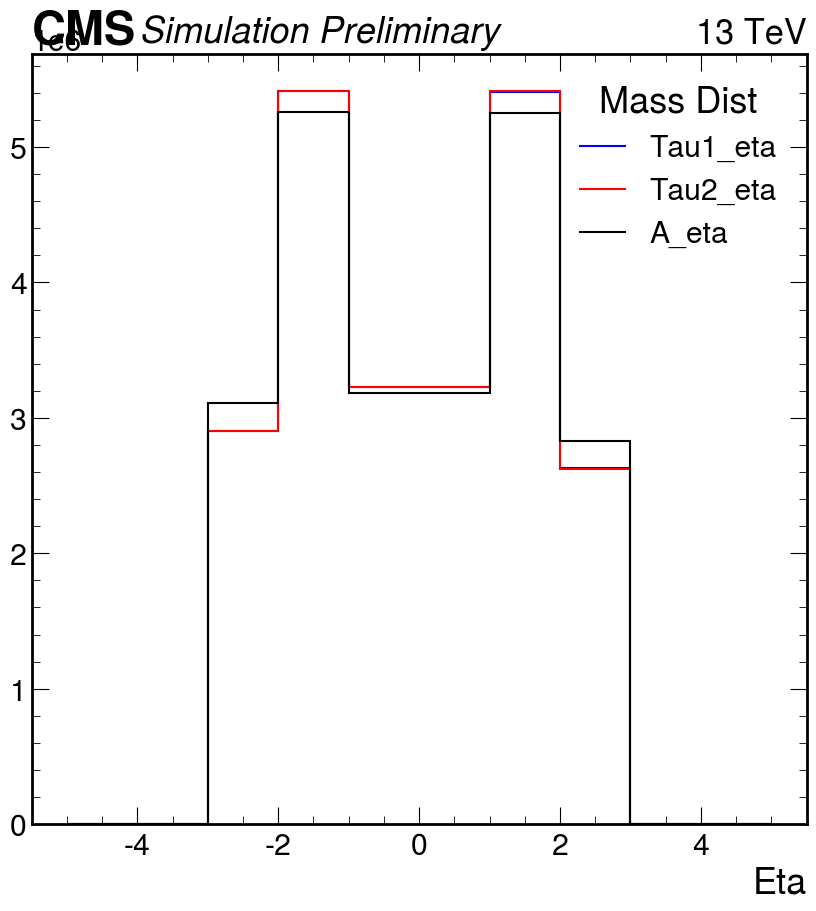

In [20]:
fig, ax = plt.subplots()
out["train_dataset_2"]["tau1_eta"].plot1d(ax=ax,histtype='step',color='b')
out["train_dataset_2"]["tau2_eta"].plot1d(ax=ax,histtype='step', color='r')
out["train_dataset_2"]["a_eta"].plot1d(ax=ax,histtype='step',color="black")
# ax.set_yscale("log")
ax.legend(title="Mass Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/eta_dist_hist.png',facecolor='w',dpi=300)

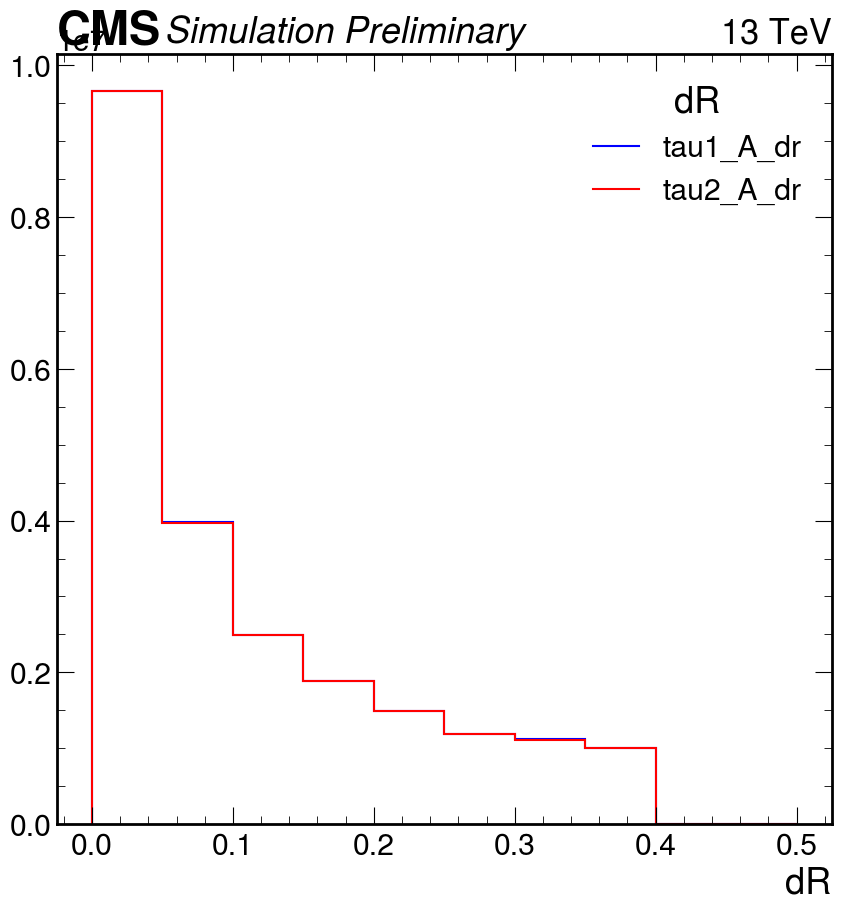

In [22]:
fig, ax = plt.subplots()
out["train_dataset_2"]["tau1_A_dr"].plot1d(ax=ax,histtype='step',color='b')
out["train_dataset_2"]["tau2_A_dr"].plot1d(ax=ax,histtype='step', color='r')

# ax.set_yscale("log")
ax.legend(title="dR")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/A_tau_dR_hist.png',facecolor='w',dpi=300)

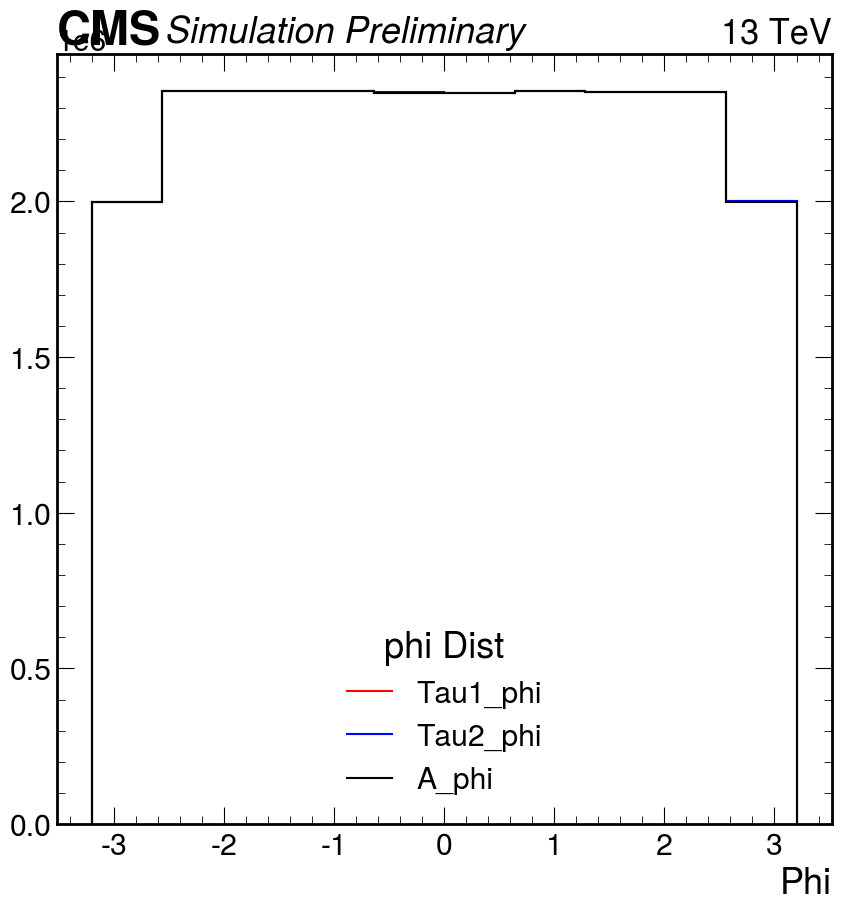

In [18]:
fig, ax = plt.subplots()
out["train_dataset_2"]["tau1_phi"].plot1d(ax=ax,histtype='step',color="r")
out["train_dataset_2"]["tau2_phi"].plot1d(ax=ax,histtype='step',color="b")
out["train_dataset_2"]["a_phi"].plot1d(ax=ax,histtype='step',color="black")
# ax.set_yscale("log")
ax.legend(title="phi Dist")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/phi_dist_hist.png',facecolor='w',dpi=300)

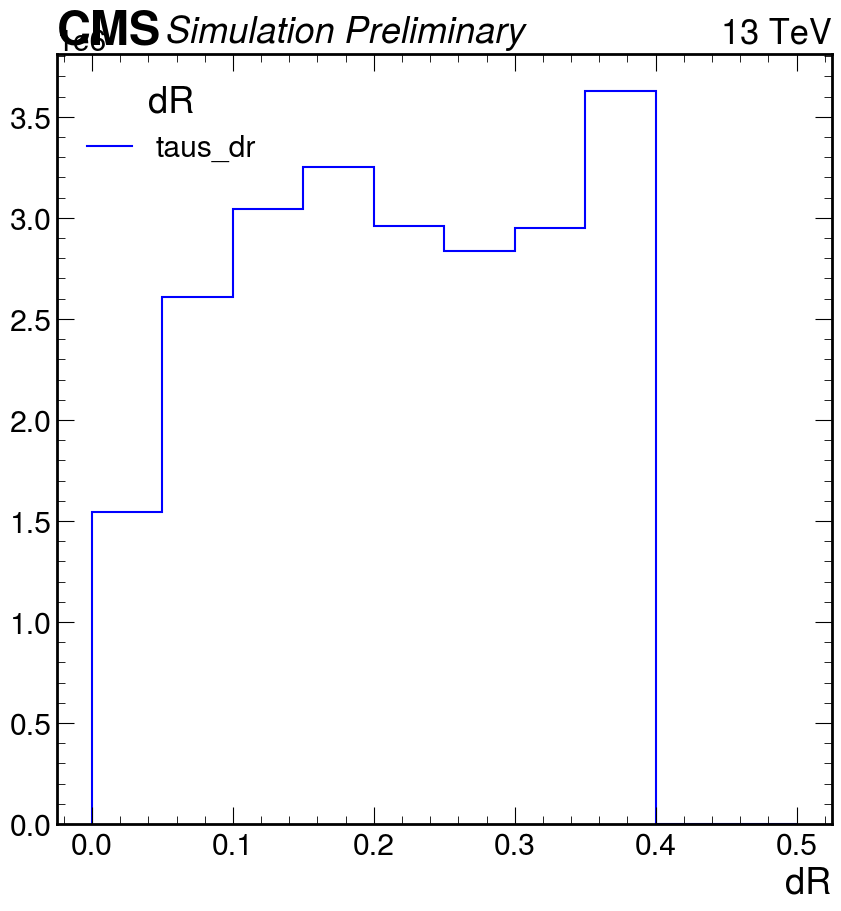

In [25]:
fig, ax = plt.subplots()
out["train_dataset_2"]["taus_dr"].plot1d(ax=ax,histtype='step',color='b')

# ax.set_yscale("log")
ax.legend(title="dR")
hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)
plt.savefig(f'plots_massreg_dataset_2/tau_tau_dR_hist.png',facecolor='w',dpi=300)